<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Salary_vs_Experience_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mubeenshehzadi/salary-dataset

# Unziping the downloaded file
!unzip salary-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mubeenshehzadi/salary-dataset
License(s): CC0-1.0
  0% 0.00/16.6k [00:00<?, ?B/s]
100% 16.6k/16.6k [00:00<00:00, 47.8MB/s]
Archive:  salary-dataset.zip
  inflating: Salary_Data.csv         


In [3]:
df = pd.read_csv('Salary_Data.csv')
df.head(11)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


In [4]:
df.tail(11)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6693,43.0,Female,Master's Degree,Sales Manager,14.0,140000.0
6694,27.0,Male,High School,Digital Marketing Manager,2.0,40000.0
6695,33.0,Female,Bachelor's Degree,Content Marketing Manager,7.0,90000.0
6696,28.0,Male,PhD,Sales Representative,4.0,55000.0
6697,51.0,Female,Master's Degree,Senior Product Marketing Manager,19.0,190000.0
6698,37.0,Male,Bachelor's Degree,Junior Sales Representative,6.0,75000.0
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [5]:
df.shape

(6704, 6)

In [6]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [7]:
df.dtypes

,0
Age,float64
Gender,object
Education Level,object
Job Title,object
Years of Experience,float64
Salary,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,6702.0,NaN,NaN,NaN,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Gender,6702,3,Male,3674,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education Level,6701,7,Bachelor's Degree,2267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Title,6702,193,Software Engineer,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years of Experience,6701.0,NaN,NaN,NaN,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,NaN,NaN,NaN,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


In [10]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [12]:
df.drop_duplicates(inplace=True)
display(df.shape)

(1792, 6)

In [13]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

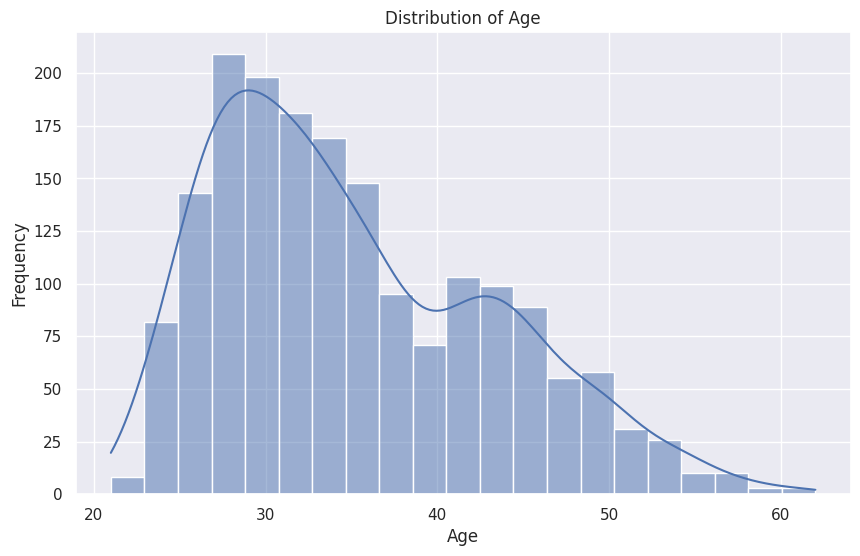

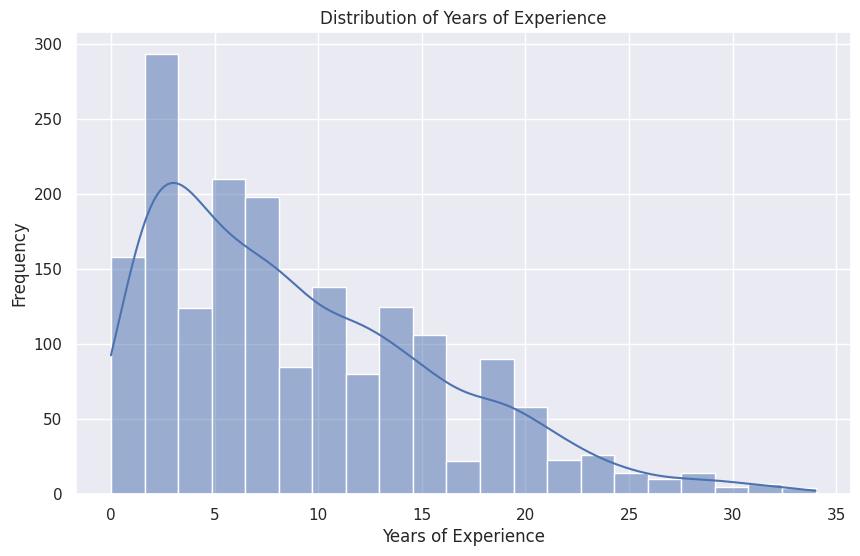

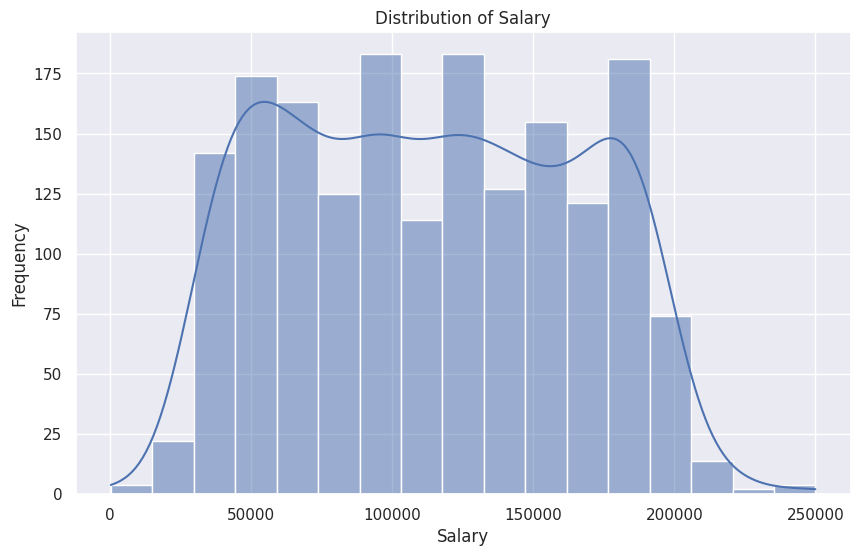

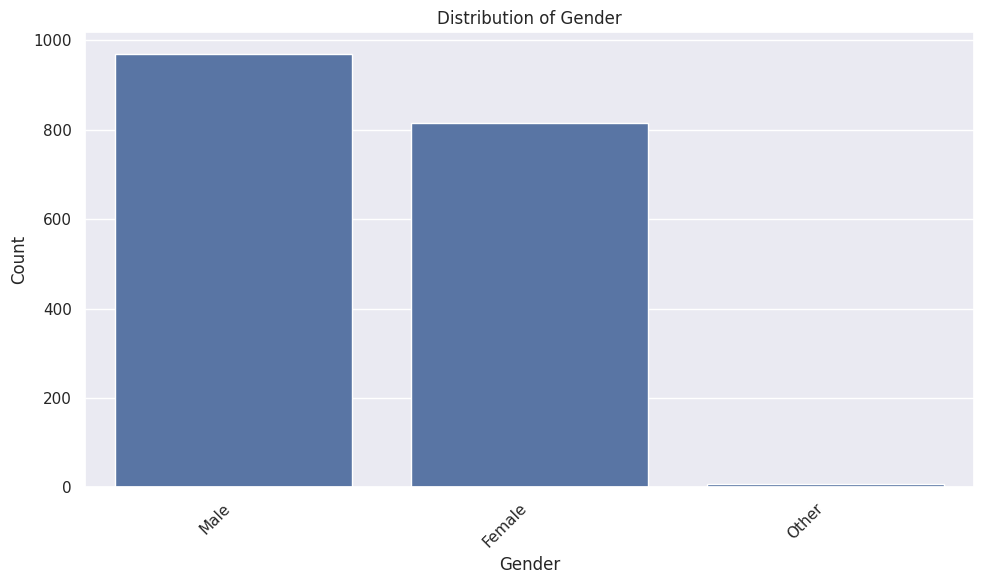

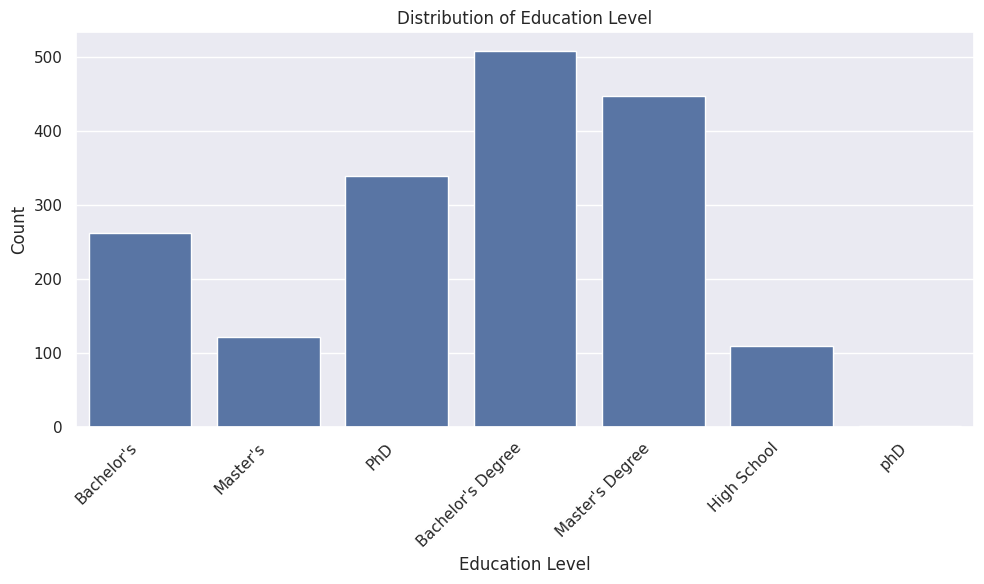

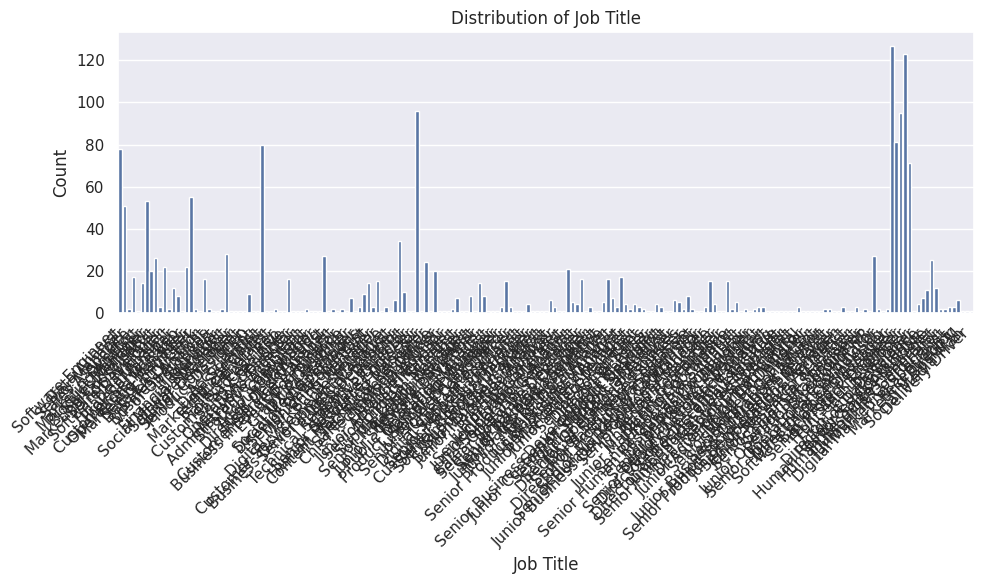

Value counts for Gender:
Gender
Male      969
Female    815
Other       7
Name: count, dtype: int64

Value counts for Education Level:
Education Level
Bachelor's Degree    508
Master's Degree      447
PhD                  340
Bachelor's           262
Master's             122
High School          110
phD                    1
Name: count, dtype: int64

Value counts for Job Title:
Job Title
Software Engineer Manager         127
Full Stack Engineer               123
Senior Software Engineer           96
Senior Project Engineer            95
Back end Developer                 81
                                 ... 
Junior Social Media Specialist      1
Developer                           1
Social M                            1
Social Media Man                    1
Delivery Driver                     1
Name: count, Length: 193, dtype: int64



In [14]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

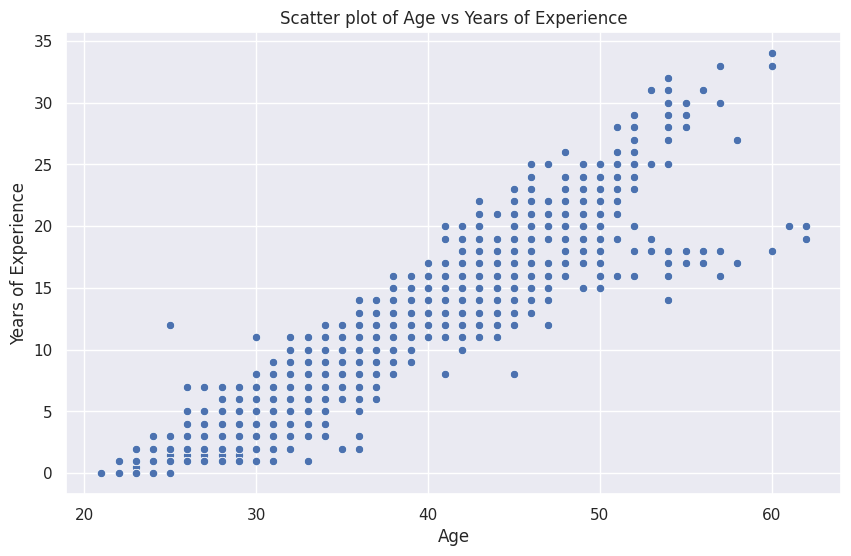

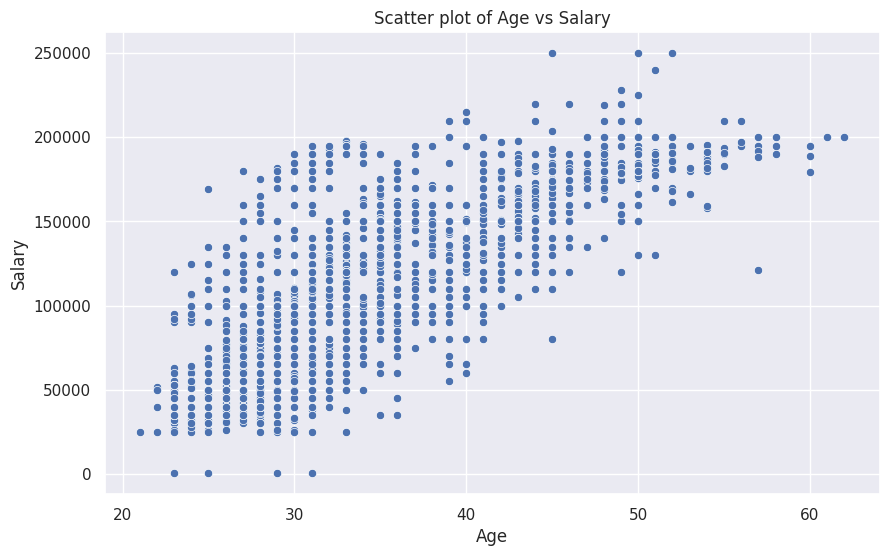

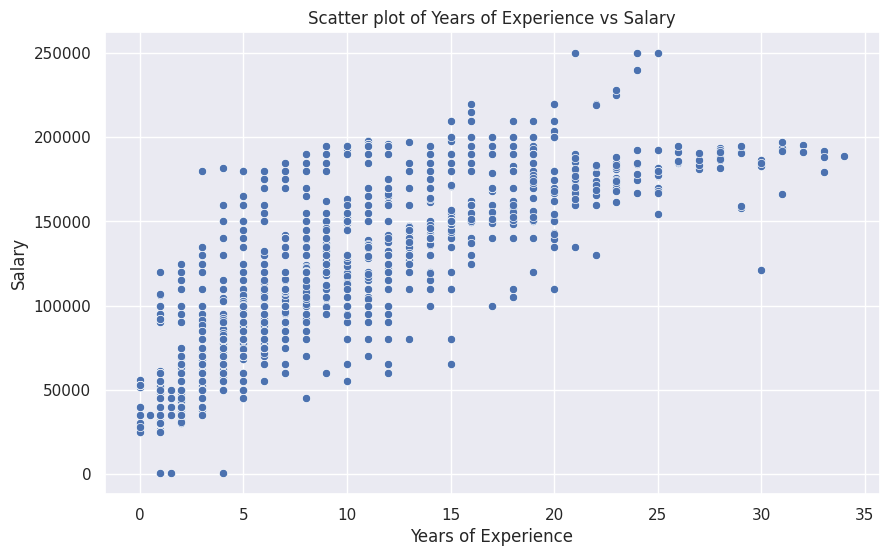

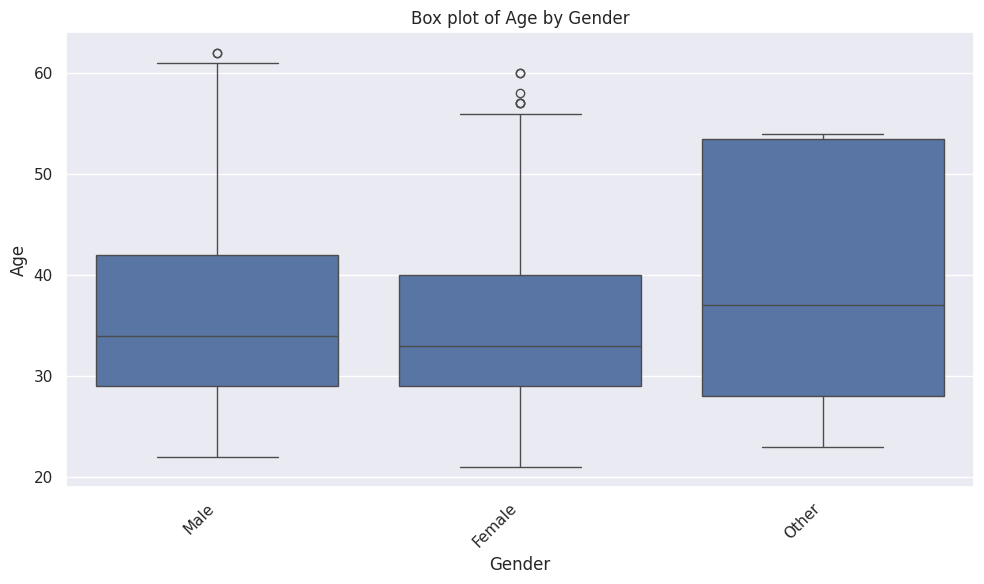

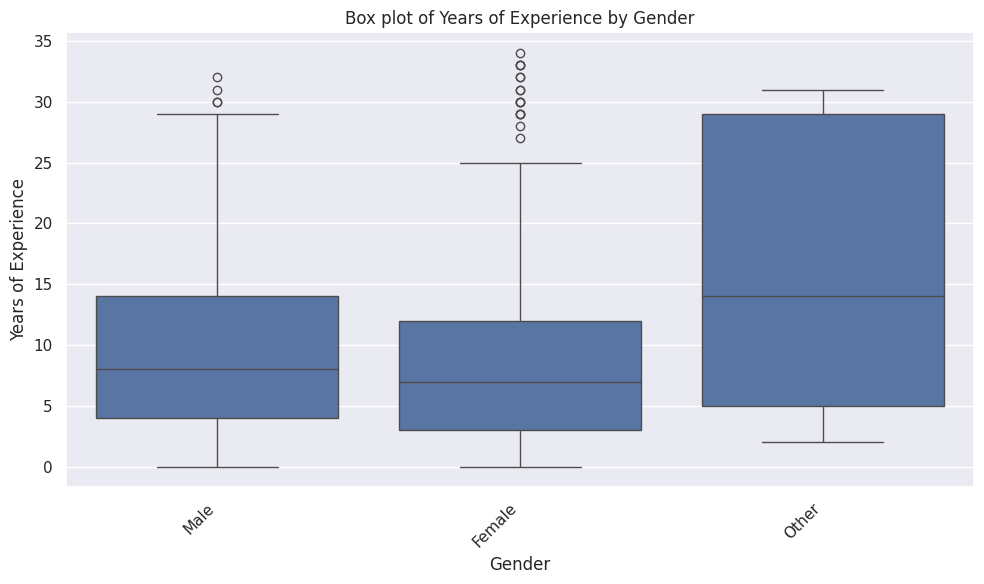

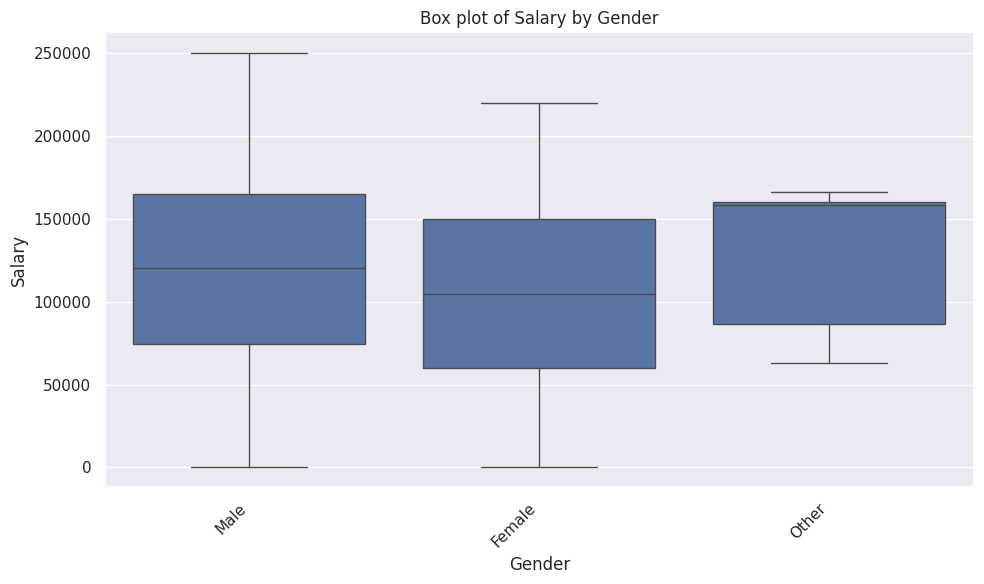

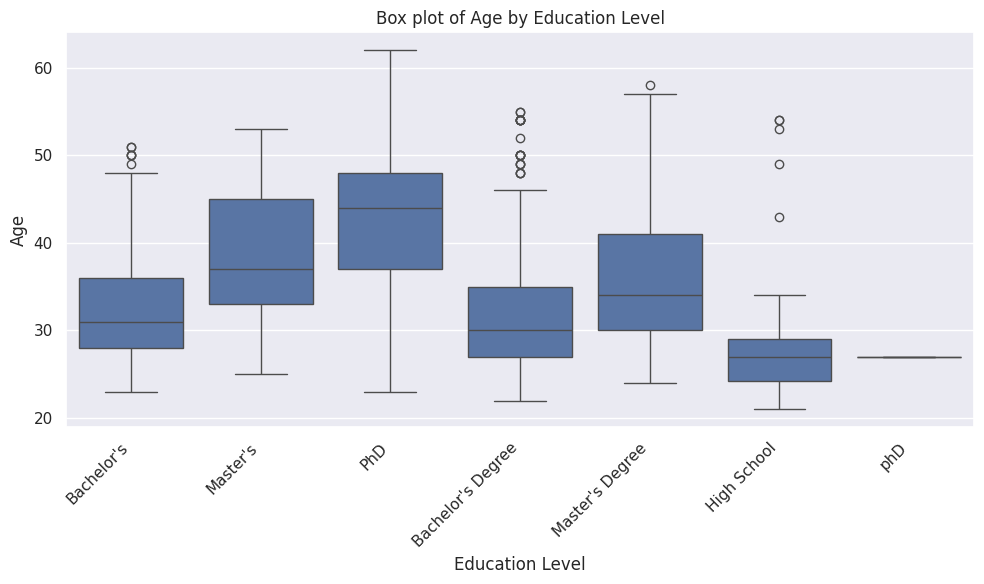

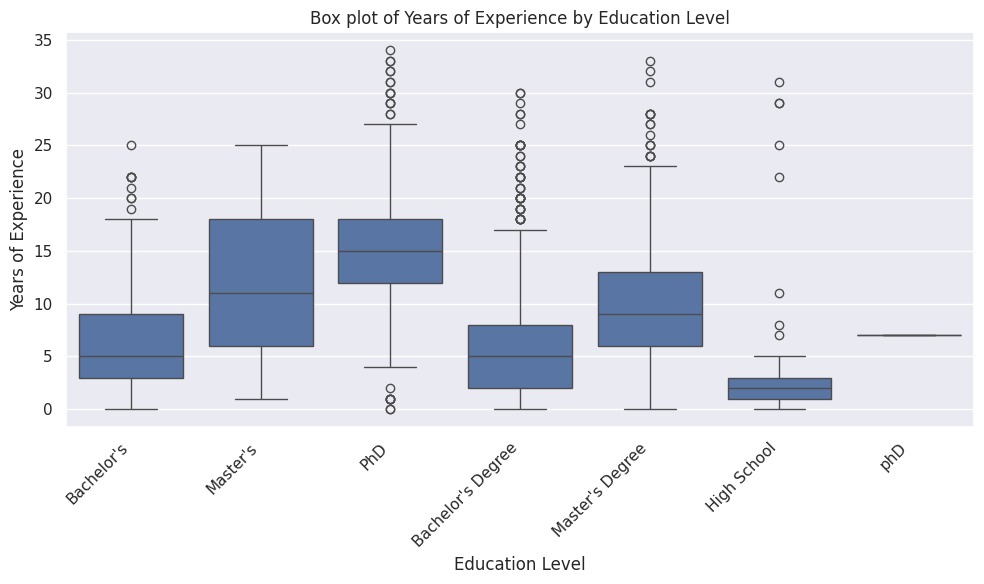

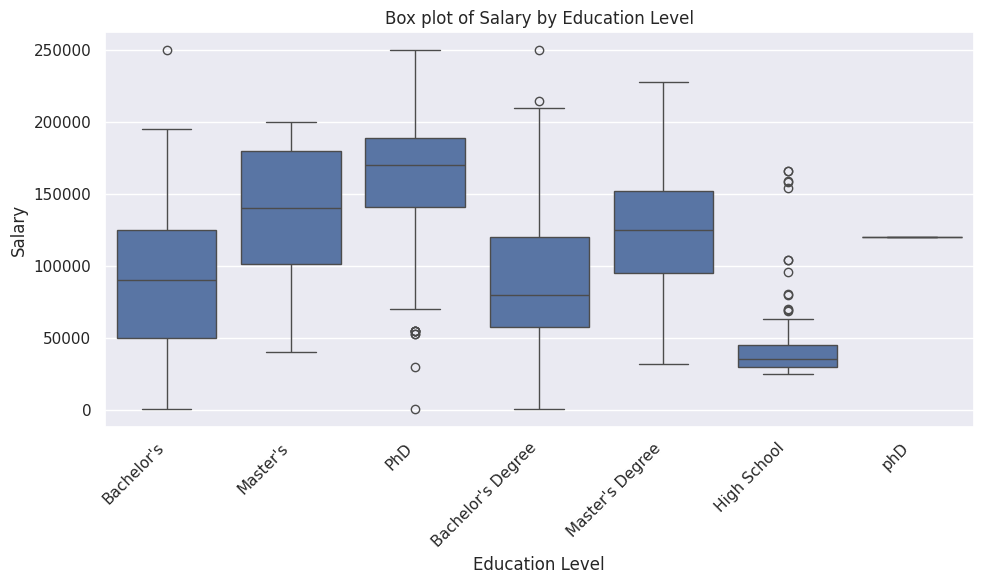

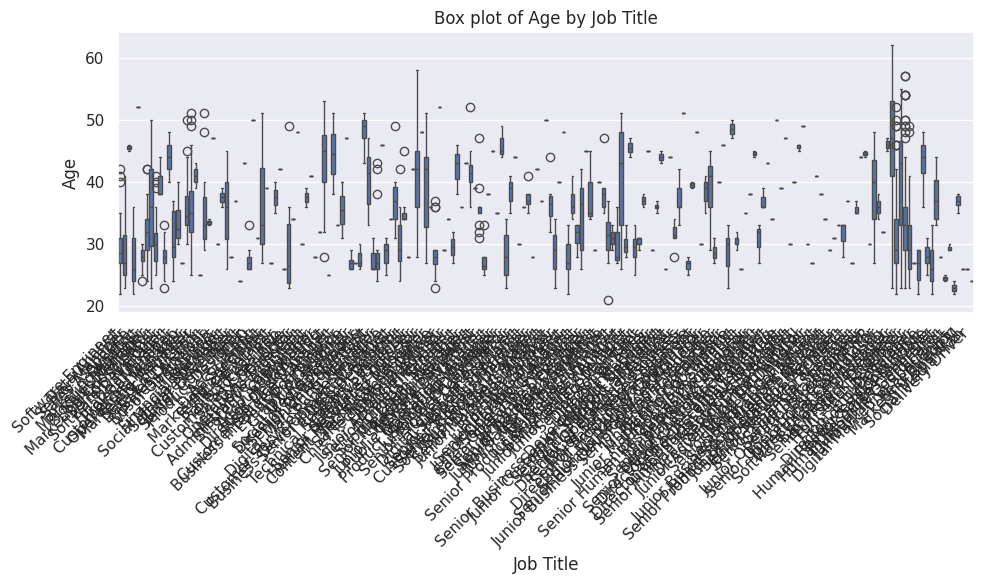

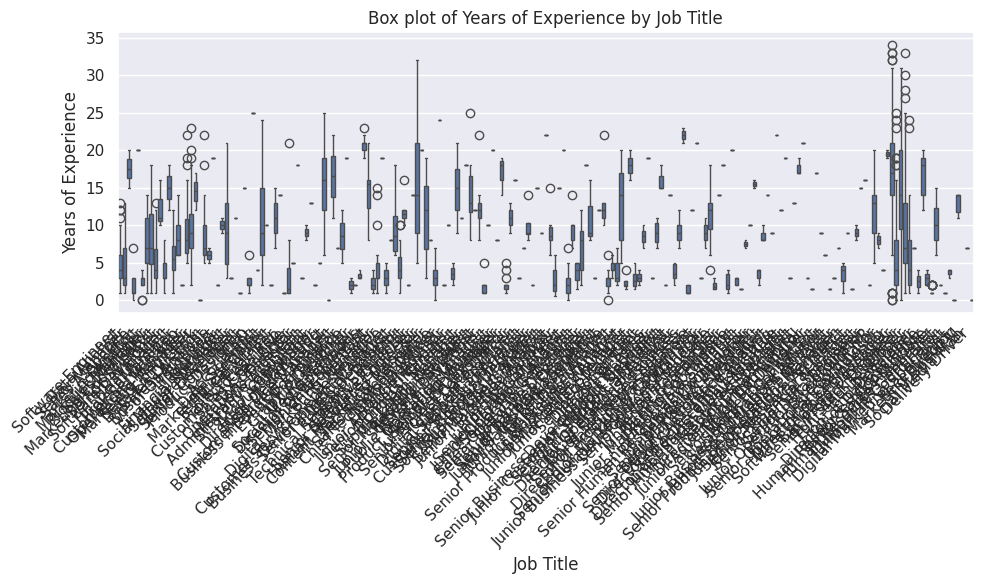

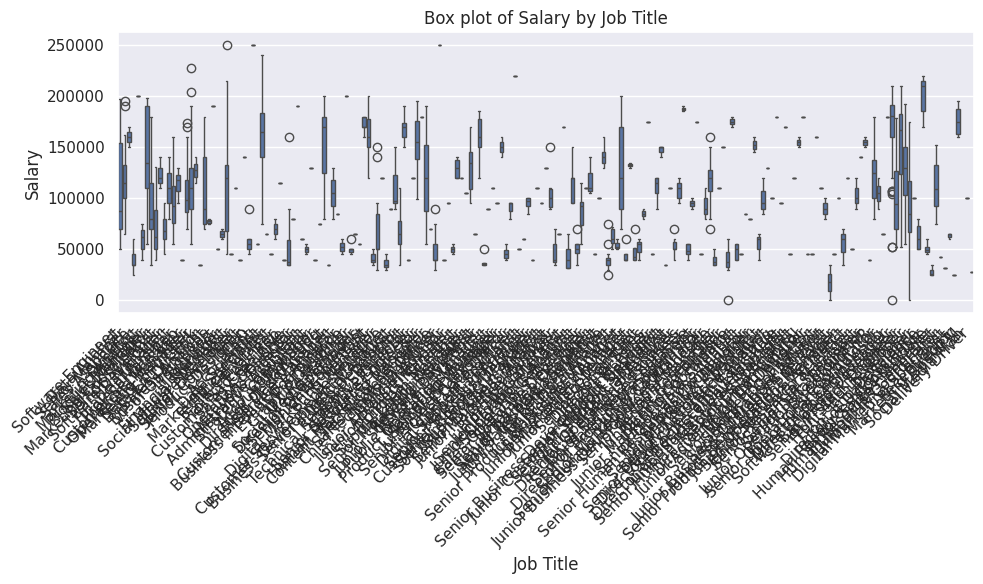

In [15]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

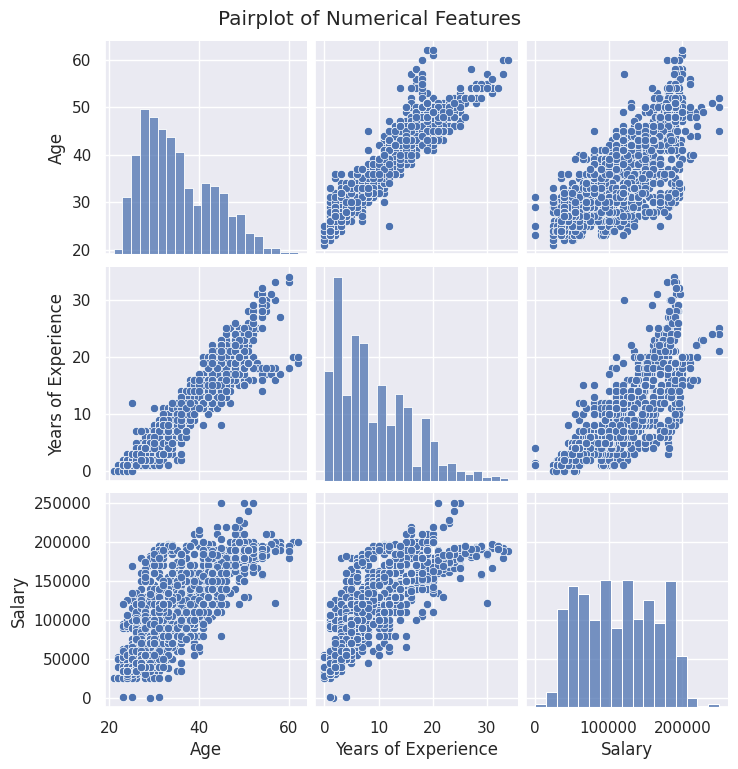

In [16]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

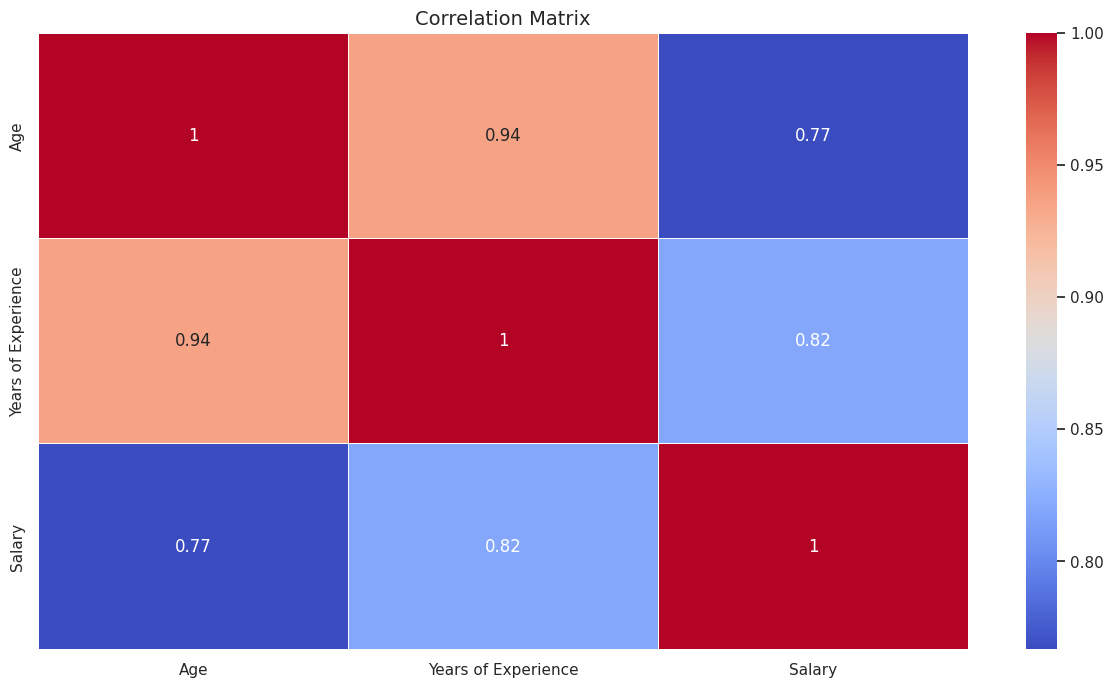

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you